# Risco de atraso em pedidos da Olist

## Desafio de negócio

Identificar, **logo após a aprovação do pagamento**, quais pedidos possuem maior risco de serem entregues depois do prazo prometido.

### Objetivos

- estimar futuramente a probabilidade de atraso de cada pedido;
- explicar os principais fatores associados ao risco;
- apoiar uma decisão operacional baseada em custos e capacidade.

> Este notebook não pretende realizar um EDA completo. Ele apresenta uma experiência reduzida e orientada por hipóteses, adequada para uma aula curta.

## Roteiro da experiência

1. Definir o alvo e o instante da previsão.
2. Carregar e verificar as tabelas.
3. Integrar os dados mantendo **uma linha por pedido**.
4. Investigar cinco perguntas orientadas por hipóteses.
5. Registrar conclusões e possíveis features.

**Pergunta central:** quais características disponíveis após a aprovação do pagamento estão associadas ao atraso?

In [1]:
# Bibliotecas para caminhos, manipulação de dados e visualização.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Configura a exibição das tabelas e o estilo dos gráficos.
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="Blues_r")


# Define os caminhos principais do projeto.
ROOT = Path.cwd().parents[0]
DATA_DIR = ROOT / "data"


# Exibe o caminho da pasta onde estão os dados.
DATA_DIR

PosixPath('/workspaces/olist-predict-main/data')

## 1. Instante da previsão e risco de data leakage

O modelo deverá gerar a previsão no instante `order_approved_at`. Assim, somente informações já conhecidas até esse momento poderão ser usadas como features.

| Disponível na previsão | Informação futura (não usar como feature) |
|---|---|
| data da compra e aprovação | data de envio à transportadora |
| prazo prometido | data real da entrega |
| cliente e localização | avaliação e comentário do cliente |
| itens, vendedores, preço e frete | status ou eventos posteriores |

> A data real da entrega será utilizada apenas para construir o target. Ela não poderá entrar como variável explicativa do modelo.

## 2. Carregamento das tabelas

Utilizaremos quatro tabelas obrigatórias para o nosso cenário

In [2]:
# Mapeia os nomes dos datasets para seus arquivos CSV.
FILES = {
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
}

# Lista as colunas que devem ser interpretadas como datas.
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

# Carrega a base de pedidos, convertendo automaticamente as colunas de data.
orders = pd.read_csv(
    DATA_DIR / "bronze" / FILES["orders"],
    parse_dates=date_columns,
)

# Carrega as bases de itens dos pedidos e clientes.
items = pd.read_csv(DATA_DIR / "bronze" / FILES["items"])
customers = pd.read_csv(DATA_DIR / "bronze" / FILES["customers"])

# Exibe a quantidade de linhas e colunas de cada base carregada.
print("Pedidos:", orders.shape)
print("Itens:", items.shape)
print("Clientes:", customers.shape)

Pedidos: (99441, 8)
Itens: (112650, 7)
Clientes: (99441, 5)


## 3. Construção do alvo

Para simplificar a experiência, usaremos apenas pedidos com status `delivered` e data real de entrega conhecida.


$$
is\_late = 1 \quad \text{se entrega real > entrega prometida}
$$


In [3]:
# Seleciona apenas os pedidos que podem ser utilizados para construir
# o histórico de entregas atrasadas e realizadas dentro do prazo.
delivered_orders = orders.loc[
    # Mantém somente pedidos que foram efetivamente entregues.
    orders["order_status"].eq("delivered")

    # Remove pedidos sem a data real em que o cliente recebeu a compra.
    # Essa data é necessária para saber se o pedido atrasou.
    & orders["order_delivered_customer_date"].notna()

    # Remove pedidos sem a data de entrega prometida ao cliente.
    # Sem essa informação, não é possível comparar o previsto com o realizado.
    & orders["order_estimated_delivery_date"].notna()

    # Mantém somente pedidos com a data de aprovação do pagamento.
    # Esse é o momento definido para realizar a previsão.
    & orders["order_approved_at"].notna()
].copy()  # Cria uma cópia independente para evitar alterações no DataFrame original.


# Cria a variável-alvo do problema:
# 1 → pedido entregue depois da data prometida;
# 0 → pedido entregue dentro do prazo ou antes da data prometida.
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"]
).astype("int8")  # Armazena 0 e 1 usando um tipo inteiro que ocupa menos memória.


# Apresenta a quantidade total de pedidos antes da aplicação dos filtros.
print(f"Pedidos originais: {len(orders):,}")


# Apresenta quantos pedidos permaneceram após aplicação do filtro
print(f"Pedidos filtrados: {len(delivered_orders):,}")


# Mostra a quantidade de pedidos em cada classe:
# 0 = entregue no prazo;
# 1 = entregue com atraso.
display(
    delivered_orders["is_late"].value_counts(dropna=False)
)

Pedidos originais: 99,441
Pedidos filtrados: 96,456


is_late
0    88630
1     7826
Name: count, dtype: int64

## 4. Integração no nível do pedido

A tabela de itens tem várias linhas para o mesmo pedido. Antes do `merge`, precisamos agregá-la. Caso contrário, a unidade de análise deixaria de ser o pedido e alguns pedidos teriam peso maior simplesmente por possuírem mais itens.

### 4.1 Agregação

In [4]:
# A tabela de itens possui uma linha para cada item presente no pedido.
# Portanto, um mesmo order_id pode aparecer várias vezes.
#
# Como o objetivo é construir uma base com uma linha por pedido,
# precisamos agrupar os itens antes de integrar essa tabela às demais.
items_agg = (
    items.groupby(
        "order_id",       # Agrupa todos os itens pertencentes ao mesmo pedido.
        as_index=False,   # Mantém order_id como uma coluna comum.
    )
    .agg(
        # Conta quantas linhas de itens existem em cada pedido.
        # Um pedido com três produtos registrados terá item_count igual a 3.
        # nome_da_nova_coluna=("coluna_original", "função")
        item_count=("order_item_id", "count"),

        # Conta quantos vendedores diferentes participam do pedido.
        # O nunique evita contar o mesmo vendedor mais de uma vez.
        # nome_da_nova_coluna=("coluna_original", "função")
        seller_count=("seller_id", "nunique"),

        # Soma os preços dos itens para obter o valor total dos produtos
        # presentes no pedido.
        # nome_da_nova_coluna=("coluna_original", "função")
        total_price=("price", "sum"),

        # Soma o frete de todos os itens para obter o valor total de frete
        # associado ao pedido.
        total_freight=("freight_value", "sum"),
    )
)


# Verifica se cada pedido aparece somente uma vez após a agregação.
#
# Se a condição for falsa, o Python interromperá a execução e lançará
# um AssertionError. Essa checagem ajuda a garantir que a unidade de
# análise da nova tabela é realmente o pedido.
assert items_agg["order_id"].is_unique


# Exibe as cinco primeiras linhas da tabela agregada.
items_agg.head()

,order_id,item_count,seller_count,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14


### 4.2 Merge

In [5]:
# Começa com os pedidos entregues que possuem as datas necessárias
# para determinar se houve atraso.
orders_analysis = (
    delivered_orders

    # Adiciona as informações agregadas dos itens:
    # quantidade de itens, vendedores, preço total e frete total.
    .merge(
        items_agg,
        on="order_id",            # Coluna usada para relacionar as tabelas.
        how="left",               # Mantém todos os pedidos de delivered_orders.
        validate="one_to_one",    # Verifica se order_id é único nas duas tabelas.
    )

    # Adiciona a localização do cliente.
    .merge(
        customers[
            ["customer_id", "customer_state", "customer_city",]
        ],
        on="customer_id",         # Relaciona cada pedido ao seu cliente.
        how="left",               # Mantém todos os pedidos da base anterior.
        validate="many_to_one",   # Vários pedidos podem apontar para um cliente.
    )
)

assert orders_analysis["order_id"].is_unique, "A base final deve manter uma linha por pedido."
assert len(orders_analysis) == len(delivered_orders), "A integração alterou o total de pedidos."

print("Dimensão da base analítica:", orders_analysis.shape)
orders_analysis.head()

Dimensão da base analítica: (96456, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,item_count,seller_count,total_price,total_freight,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,1,1,29.99,8.72,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,1,1,118.70,22.76,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,1,1,159.90,19.22,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,1,1,45.00,27.20,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,1,1,19.90,8.72,SP,santo andre


## 5. Criação de Novas Variáveis

Estas variáveis são construídas apenas com dados conhecidos até a aprovação do pagamento.

In [6]:
# Calcula quantos dias a empresa prometeu para realizar a entrega,
# considerando como início o momento da aprovação do pagamento.
orders_analysis["promised_days"] = (
    orders_analysis["order_estimated_delivery_date"]  # Data prometida para a entrega.
    - orders_analysis["order_approved_at"]            # Data de aprovação do pagamento.
).dt.total_seconds().div(86_400)          # Converte segundos para dias => 24 * 60 * 60 = 86.400 segundos


# Extrai o número do mês em que a compra foi realizada.
# Exemplo: janeiro = 1, fevereiro = 2, ..., dezembro = 12.
orders_analysis["purchase_month"] = (
    orders_analysis["order_purchase_timestamp"].dt.month
)


# Extrai o dia da semana em que a compra foi realizada.
#
# O Pandas representa os dias da seguinte forma:
# 0 = segunda-feira
# 1 = terça-feira
# 2 = quarta-feira
# 3 = quinta-feira
# 4 = sexta-feira
# 5 = sábado
# 6 = domingo
orders_analysis["purchase_weekday"] = (
    orders_analysis["order_purchase_timestamp"].dt.dayofweek
)


# Extrai a hora em que a compra foi realizada.
# Os valores variam de 0 a 23.
#
# Exemplo:
# 0  = meia-noite
# 8  = 8 horas
# 14 = 14 horas
# 23 = 23 horas
orders_analysis["purchase_hour"] = (
    orders_analysis["order_purchase_timestamp"].dt.hour
)


# Gera estatísticas descritivas para o prazo prometido:
# quantidade, média, desvio-padrão, mínimo, quartis e máximo.
#
# describe() gera as estatísticas.
# to_frame() transforma o resultado em DataFrame.
# .T transpõe a tabela para que as estatísticas apareçam como colunas.
display(
    orders_analysis["promised_days"].describe().to_frame().T
)


# Conta quantos pedidos apresentam prazo prometido menor ou igual a zero.
#
# Esses casos seriam suspeitos porque significariam que a data prometida
# ocorreu antes ou exatamente no momento da aprovação do pagamento.
print(
    "Prazos não positivos:",
    orders_analysis["promised_days"].le(0).sum()
)

,count,mean,std,min,25%,50%,75%,max
promised_days,96456.0,23.306482,8.765103,-6.664225,17.905885,22.668762,28.066727,153.57603


Prazos não positivos: 6


# Pergunta 1: Qual é a frequência de pedidos atrasados?

**Hipótese:** os atrasos são minoritários, produzindo desbalanceamento entre as classes.

**Discussão:** se um modelo sempre previsse “não atrasará”, qual seria sua acurácia? Ela seria suficiente para avaliar o modelo?

In [7]:
display(
    delivered_orders["is_late"].value_counts(dropna=False)
)


is_late
0    88630
1     7826
Name: count, dtype: int64

**Conclusão da pergunta 1:** escreva aqui o que os dados mostraram.

- Taxa de atraso: `8%`
- A hipótese foi apoiada? `Sim`
- Implicação para a modelagem: `A acurácia seria alta, porém não identificaria os atrasos, então não é a melhor métrica.`

# Pergunta 2: Pedidos com prazos menores atrasam mais?

**Hipótese:** quando a empresa promete entregar em poucos dias, existe menos
margem para problemas logísticos e o pedido pode apresentar maior risco de atraso.


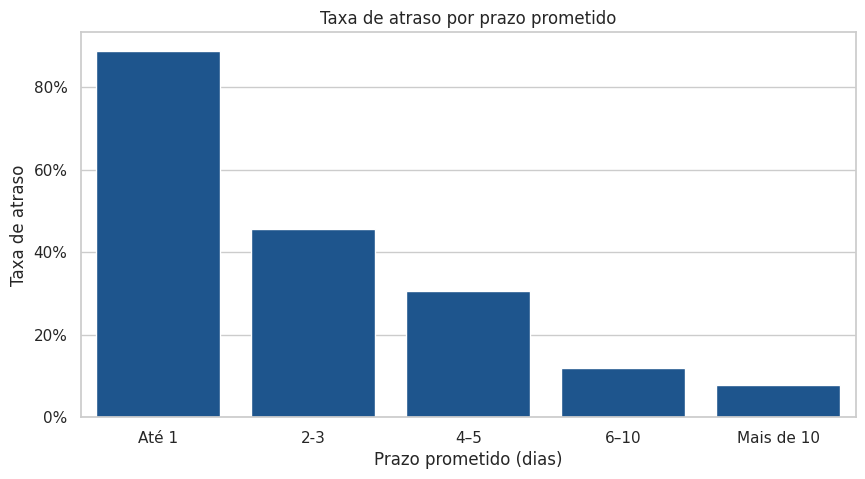

In [8]:
# Cria faixas para o prazo prometido.
orders_analysis["promised_days_range"] = pd.cut(
    orders_analysis["promised_days"],
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=["Até 1", "2-3","4–5", "6–10", "Mais de 10"],
)

# Calcula a taxa de atraso e a quantidade de pedidos em cada faixa.
delay_by_range = (
    orders_analysis
    .groupby("promised_days_range", observed=True)
    .agg(
        delay_rate=("is_late", "mean"),
        order_count=("order_id", "count"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=delay_by_range,
    x="promised_days_range",
    y="delay_rate",
)

plt.title("Taxa de atraso por prazo prometido")
plt.xlabel("Prazo prometido (dias)")
plt.ylabel("Taxa de atraso")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.show()

A taxa de atraso diminui de forma consistente à medida que o prazo prometido aumenta. Entregas com prazo de até 1 dia apresentam a maior taxa de atraso, acima de 80%, enquanto pedidos com prazos superiores a 10 dias apresentam menos de 10% de atraso.


# Pergunta 3: Pedidos maiores ou mais complexos atrasam mais?

**Hipótese:** pedidos com mais itens ou vendedores apresentam maior complexidade logística e maior risco.

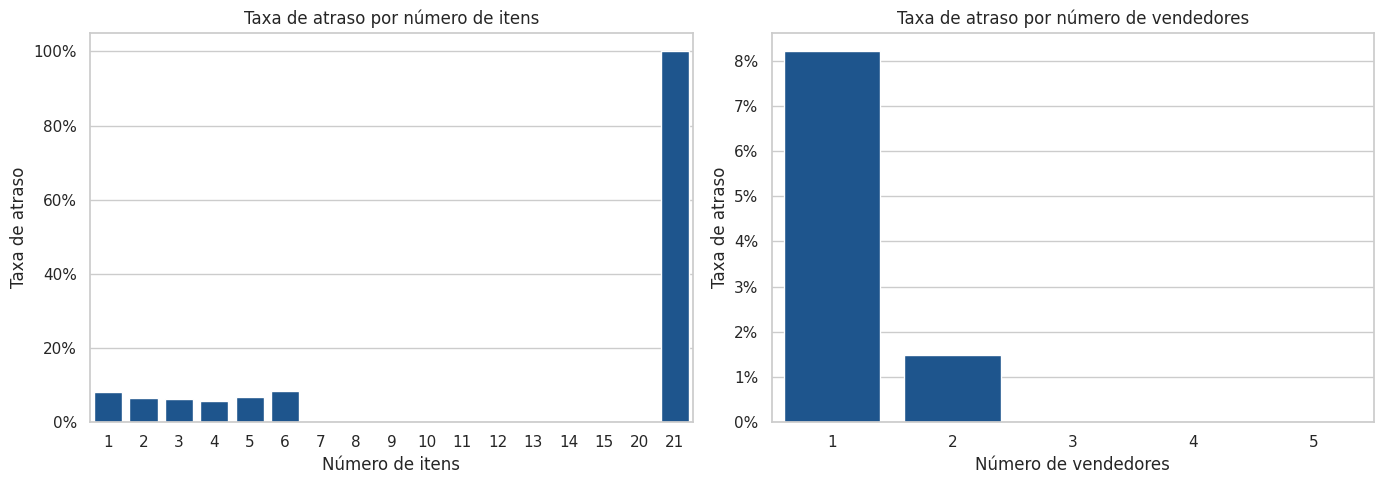

,item_count,delay_rate,order_count,order_count_cumsum,order_count_cumsum_pct
0,1,0.082894,86822,86822,0.900120
1,2,0.066297,7391,94213,0.976746
2,3,0.062021,1306,95519,0.990286
3,4,0.056566,495,96014,0.995418
4,5,0.067358,193,96207,0.997419
5,6,0.083770,191,96398,0.999399
6,7,0.000000,22,96420,0.999627
7,8,0.000000,8,96428,0.999710
8,9,0.000000,3,96431,0.999741
9,10,0.000000,8,96439,0.999824


,seller_count,delay_rate,order_count,order_count_cumsum,order_count_cumsum_pct
0,1,0.082033,95181,95181,0.986782
1,2,0.014803,1216,96397,0.999388
2,3,0.000000,54,96451,0.999948
3,4,0.000000,3,96454,0.999979
4,5,0.000000,2,96456,1.000000


In [9]:
# Taxa de atraso por número de itens
delay_by_items = (
    orders_analysis
    .groupby("item_count")
    .agg(
        delay_rate=("is_late", "mean"),
        order_count=("order_id", "count"),
    )
    .reset_index()
)

# Cumulativo de pedidos
delay_by_items["order_count_cumsum"] = (
    delay_by_items["order_count"].cumsum()
)

delay_by_items["order_count_cumsum_pct"] = (
    delay_by_items["order_count_cumsum"]
    / delay_by_items["order_count"].sum()
)


# Taxa de atraso por número de vendedores
delay_by_sellers = (
    orders_analysis
    .groupby("seller_count")
    .agg(
        delay_rate=("is_late", "mean"),
        order_count=("order_id", "count"),
    )
    .reset_index()
)

# Cumulativo de pedidos
delay_by_sellers["order_count_cumsum"] = (
    delay_by_sellers["order_count"].cumsum()
)

delay_by_sellers["order_count_cumsum_pct"] = (
    delay_by_sellers["order_count_cumsum"]
    / delay_by_sellers["order_count"].sum()
)


# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=delay_by_items,
    x="item_count",
    y="delay_rate",
    ax=axes[0],
)

axes[0].set_title("Taxa de atraso por número de itens")
axes[0].set_xlabel("Número de itens")
axes[0].set_ylabel("Taxa de atraso")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

sns.barplot(
    data=delay_by_sellers,
    x="seller_count",
    y="delay_rate",
    ax=axes[1],
)

axes[1].set_title("Taxa de atraso por número de vendedores")
axes[1].set_xlabel("Número de vendedores")
axes[1].set_ylabel("Taxa de atraso")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.tight_layout()
plt.show()

display(delay_by_items)
display(delay_by_sellers)

**Conclusão da pergunta 3:** diferenças nas medianas parecem operacionalmente relevantes? Os boxplots mostram muita sobreposição?


# Pergunta 4: O risco varia geograficamente?

**Hipótese:** alguns estados apresentam maior risco devido à distância ou à infraestrutura logística.

Para evitar conclusões instáveis, mostraremos apenas estados com pelo menos 100 pedidos no recorte.

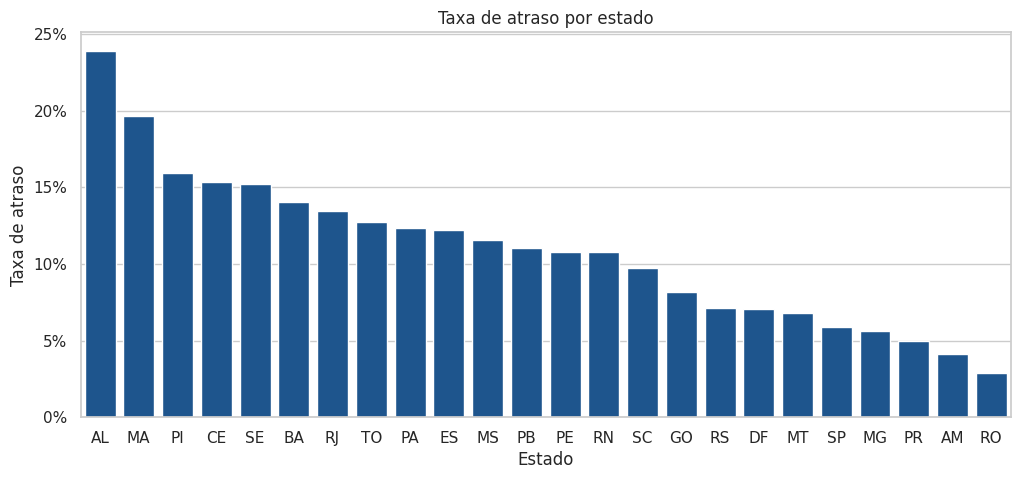

,customer_state,delay_rate,order_count
1,AL,0.239295,397
9,MA,0.196927,716
16,PI,0.159664,476
5,CE,0.153365,1278
24,SE,0.152239,335
4,BA,0.140356,3256
18,RJ,0.134759,12348
26,TO,0.127737,274
13,PA,0.123679,946
7,ES,0.122306,1995


In [10]:
# Taxa de atraso por estado
delay_by_state = (
    orders_analysis
    .groupby("customer_state")
    .agg(
        delay_rate=("is_late", "mean"),
        order_count=("order_id", "count"),
    )
    .reset_index()
)

# Mantém estados com pelo menos 100 pedidos
delay_by_state = delay_by_state[
    delay_by_state["order_count"] >= 100
].copy()

# Ordena pela maior taxa de atraso
delay_by_state = delay_by_state.sort_values(
    "delay_rate",
    ascending=False
)

# Gráfico
plt.figure(figsize=(12, 5))

sns.barplot(
    data=delay_by_state,
    x="customer_state",
    y="delay_rate",
)

plt.title("Taxa de atraso por estado")
plt.xlabel("Estado")
plt.ylabel("Taxa de atraso")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.show()

display(delay_by_state)

A taxa de atraso apresenta variação relevante entre os estados, indicando uma associação entre localização geográfica e risco de atraso. Estados como AL e MA apresentam taxas próximas ou superiores a 20%, enquanto SP, MG e PR permanecem próximas de 5%. Essa diferença pode refletir outros fatores logísticos associados à localização, como distância entre vendedor e cliente e infraestrutura de entrega.



# Pergunta 5: O momento da compra está associado ao atraso?

**Hipótese:** determinados meses enfrentam maior pressão logística e apresentam maior taxa de atraso.

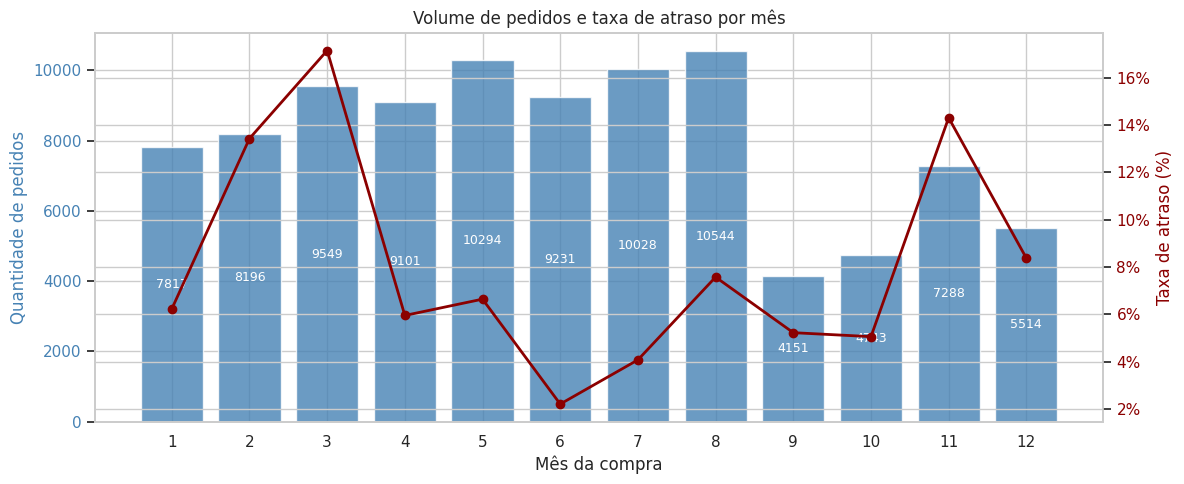

,purchase_month,delay_rate,order_count
0,1,0.062300,7817
1,2,0.134334,8196
2,3,0.171536,9549
3,4,0.059554,9101
4,5,0.066446,10294
5,6,0.022099,9231
6,7,0.040786,10028
7,8,0.075778,10544
8,9,0.052277,4151
9,10,0.050601,4743


In [11]:
# Análise mensal
delay_by_month = (
    orders_analysis
    .groupby("purchase_month")
    .agg(
        delay_rate=("is_late", "mean"),
        order_count=("order_id", "count"),
    )
    .reset_index()
)

delay_by_month = delay_by_month.sort_values("purchase_month")

# Gráfico
fig, ax1 = plt.subplots(figsize=(12, 5))

# Barras: quantidade de pedidos - eixo Y esquerdo
bars = ax1.bar(
    delay_by_month["purchase_month"].astype(str),
    delay_by_month["order_count"],
    color="steelblue",
    alpha=0.8,
)

ax1.set_title("Volume de pedidos e taxa de atraso por mês")
ax1.set_xlabel("Mês da compra")
ax1.set_ylabel("Quantidade de pedidos", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Rótulos centralizados nas barras
ax1.bar_label(
    bars,
    labels=delay_by_month["order_count"],
    label_type="center",
    color="white",
    fontsize=9,
)

# Linha: taxa de atraso - eixo Y direito
ax2 = ax1.twinx()

ax2.plot(
    range(len(delay_by_month)),
    delay_by_month["delay_rate"],
    color="darkred",
    marker="o",
    linewidth=2,
)

ax2.set_ylabel("Taxa de atraso (%)", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.tight_layout()
plt.show()

display(delay_by_month)

A taxa de atraso apresenta variação relevante entre os meses, com picos em março (17,2%), novembro (14,3%) e fevereiro (13,4%). Entretanto, esses picos não acompanham diretamente o volume de pedidos, indicando que a quantidade de pedidos, isoladamente, não parece explicar a variação mensal dos atrasos. Porém, importante verificar sazionalidade funturamente entre ano-mês

